---
### **Question 1**
> **Q1. Ask the user to enter a value (e.g., M) for a mathematical function.**
> - Generate $x$ values from $-10$ to $10$ using `np.linspace()`.
> - Compute $y$ values for:
>   - $y = M \cdot x^2$
>   - $y = M \cdot \sin(x)$
> - Plot both functions in a single figure:
>   - Use different colors and line styles.
>   - Add legend, grid, and title.


Selected Parameter Value M = 5.0


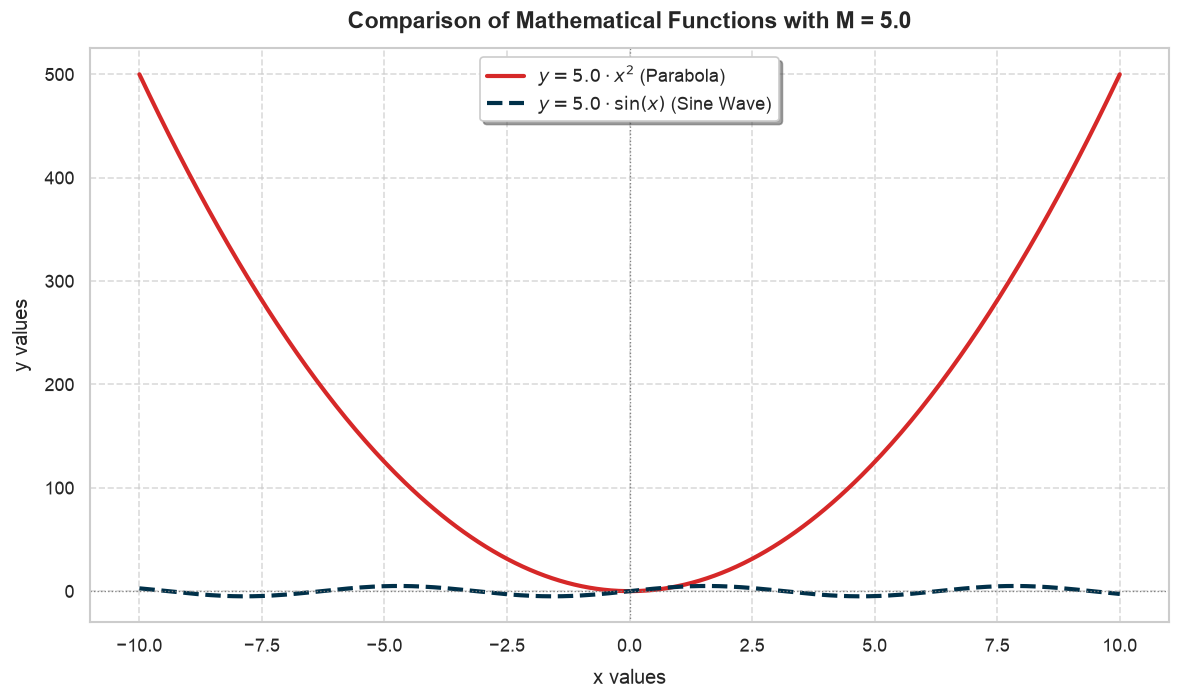

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import sys

sns.set_theme(style="whitegrid")
plt.rcParams['font.sans-serif'] = 'Arial'
plt.rcParams['figure.dpi'] = 120

try:
    if hasattr(sys.stdin, 'isatty') and sys.stdin.isatty():
        user_val = input("Enter a value for M (or press Enter for default M = 5): ").strip()
        M = float(user_val) if user_val else 5.0
    else:
        M = 5.0
except Exception:
    M = 5.0

print(f"Selected Parameter Value M = {M}")

x = np.linspace(-10, 10, 400)

y_parabola = M * (x ** 2)
y_sine = M * np.sin(x)

plt.figure(figsize=(10, 6))

plt.plot(x, y_parabola, color='#D62828', linestyle='-', linewidth=2.5, label=rf'$y = {M} \cdot x^2$ (Parabola)')

plt.plot(x, y_sine, color='#003049', linestyle='--', linewidth=2.5, label=rf'$y = {M} \cdot \sin(x)$ (Sine Wave)')

plt.title(f'Comparison of Mathematical Functions with M = {M}', fontsize=14, fontweight='bold', pad=12)
plt.xlabel('x values', fontsize=12, labelpad=8)
plt.ylabel('y values', fontsize=12, labelpad=8)
plt.axhline(0, color='gray', linewidth=0.8, linestyle=':')
plt.axvline(0, color='gray', linewidth=0.8, linestyle=':')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(fontsize=11, loc='upper center', frameon=True, shadow=True)
plt.tight_layout()
plt.show()


---
### **Question 2**
> **Q.2 Create a dataset of five subjects and scores.**
> - Convert it into a Pandas DataFrame.
> - Plot the scores using a Seaborn bar plot with:
>   - Different colors for each bar.
>   - Annotations on top of each bar.
>   - Title, axis labels, and grid.


DataFrame of Subjects and Scores:


,Subject,Score
0,Cognitive Computing,94
1,Machine Learning,88
2,Data Science,96
3,Artificial Intelligence,85
4,Neural Networks,91


/var/folders/kt/jj9bj6hn4xz11841mz81pdx00000gn/T/ipykernel_16727/2119175720.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


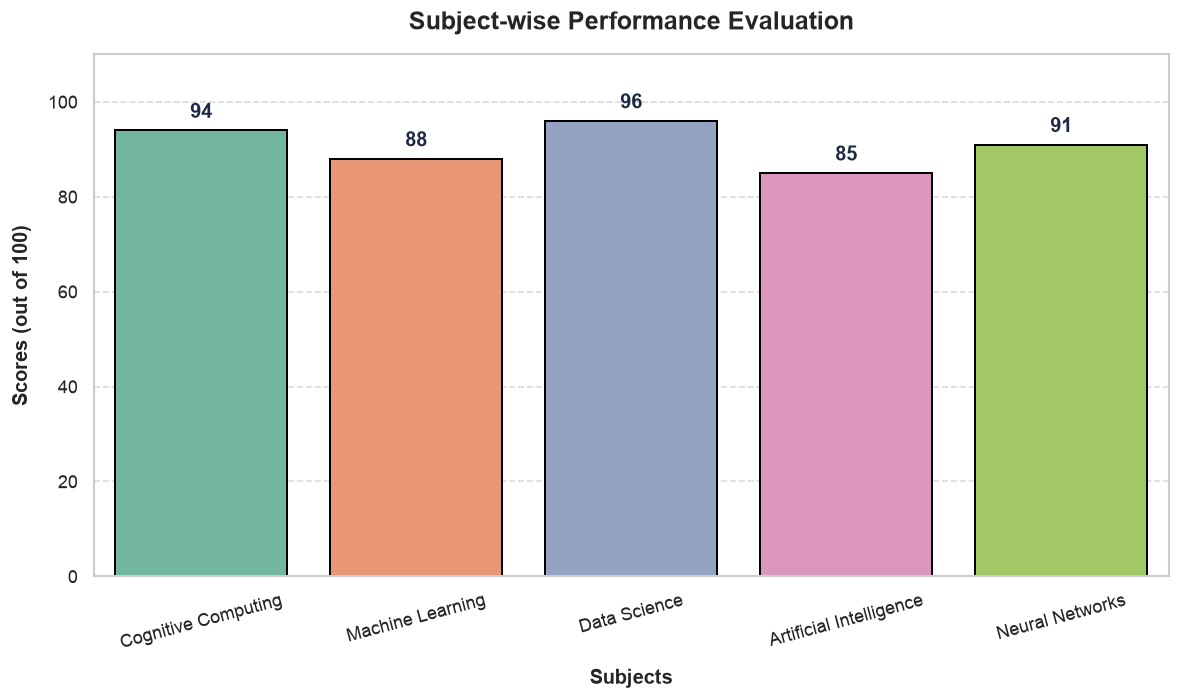

In [2]:
scores_data = {
    "Subject": ["Cognitive Computing", "Machine Learning", "Data Science", "Artificial Intelligence", "Neural Networks"],
    "Score": [94, 88, 96, 85, 91]
}

df_scores = pd.DataFrame(scores_data)
print("DataFrame of Subjects and Scores:")
display(df_scores)

plt.figure(figsize=(10, 6))
colors = sns.color_palette("Set2", n_colors=len(df_scores))

ax = sns.barplot(
    data=df_scores,
    x="Subject",
    y="Score",
    palette=colors,
    edgecolor="black",
    linewidth=1.2
)

for p in ax.patches:
    val = p.get_height()
    ax.annotate(
        f'{int(val)}',
        (p.get_x() + p.get_width() / 2., val),
        ha='center', va='bottom',
        xytext=(0, 5), textcoords='offset points',
        fontsize=12, fontweight='bold', color='#1D2A44'
    )

plt.title("Subject-wise Performance Evaluation", fontsize=15, fontweight='bold', pad=15)
plt.xlabel("Subjects", fontsize=12, fontweight='bold', labelpad=10)
plt.ylabel("Scores (out of 100)", fontsize=12, fontweight='bold', labelpad=10)
plt.ylim(0, 110)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(fontsize=10.5, rotation=15)
plt.tight_layout()
plt.show()


---
### **Question 3**
> **Q3. Write a Python script to select your roll number as seed for NumPy and then generate a dataset of 50 values using `np.random.randn()`.**
> - Create a 2x2 subplot layout displaying:
>   - Line plot showing cumulative sum.
>   - Scatter plot with random noise.
> - Customize with titles, axis labels, and grids.


NumPy Random Seed set to Roll Number: 1024170154
Generated 50 random values (first 10 shown):
 [-0.257   2.2361 -0.1234 -2.1522 -0.0515  0.7369 -0.1103  0.8022  0.3367
  1.5907]


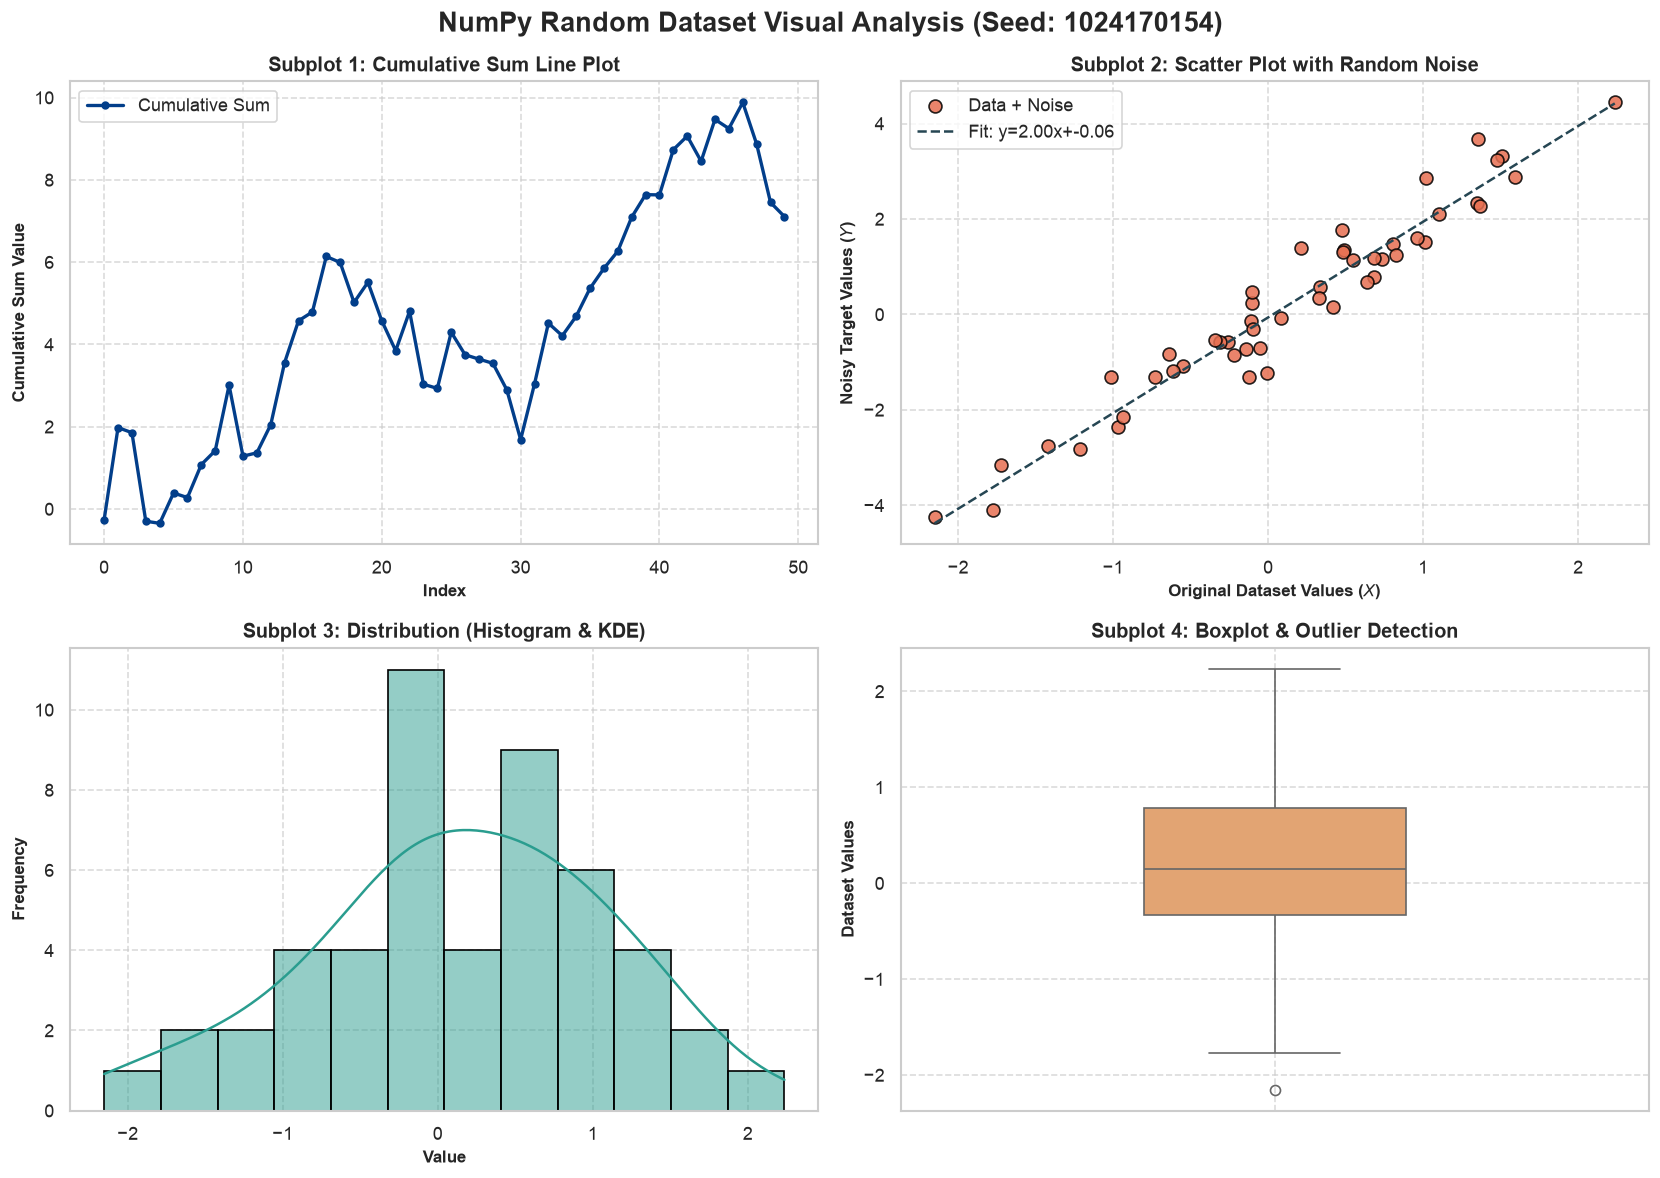

In [3]:
roll_seed = int("1024170154")
np.random.seed(roll_seed)
print("NumPy Random Seed set to Roll Number:", roll_seed)

dataset_50 = np.random.randn(50)
print("Generated 50 random values (first 10 shown):\n", np.round(dataset_50[:10], 4))

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(f'NumPy Random Dataset Visual Analysis (Seed: {roll_seed})', fontsize=16, fontweight='bold', y=0.98)

cum_sum = np.cumsum(dataset_50)
axes[0, 0].plot(cum_sum, color='#023E8A', marker='o', markersize=4, linestyle='-', linewidth=2, label='Cumulative Sum')
axes[0, 0].set_title('Subplot 1: Cumulative Sum Line Plot', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Index', fontsize=10, fontweight='bold')
axes[0, 0].set_ylabel('Cumulative Sum Value', fontsize=10, fontweight='bold')
axes[0, 0].grid(True, linestyle='--', alpha=0.7)
axes[0, 0].legend()

np.random.seed(roll_seed + 1)
noise = np.random.normal(0, 0.5, 50)
y_with_noise = 2.0 * dataset_50 + noise
axes[0, 1].scatter(dataset_50, y_with_noise, color='#E76F51', edgecolors='black', s=60, alpha=0.85, label='Data + Noise')
slope, intercept = np.polyfit(dataset_50, y_with_noise, 1)
axes[0, 1].plot(np.sort(dataset_50), slope * np.sort(dataset_50) + intercept, color='#264653', linestyle='--', label=f'Fit: y={slope:.2f}x+{intercept:.2f}')
axes[0, 1].set_title('Subplot 2: Scatter Plot with Random Noise', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Original Dataset Values ($X$)', fontsize=10, fontweight='bold')
axes[0, 1].set_ylabel('Noisy Target Values ($Y$)', fontsize=10, fontweight='bold')
axes[0, 1].grid(True, linestyle='--', alpha=0.7)
axes[0, 1].legend()

sns.histplot(dataset_50, kde=True, ax=axes[1, 0], color='#2A9D8F', bins=12, edgecolor='black')
axes[1, 0].set_title('Subplot 3: Distribution (Histogram & KDE)', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Value', fontsize=10, fontweight='bold')
axes[1, 0].set_ylabel('Frequency', fontsize=10, fontweight='bold')
axes[1, 0].grid(True, linestyle='--', alpha=0.7)

sns.boxplot(y=dataset_50, ax=axes[1, 1], color='#F4A261', width=0.35)
axes[1, 1].set_title('Subplot 4: Boxplot & Outlier Detection', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('Dataset Values', fontsize=10, fontweight='bold')
axes[1, 1].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


---
### **Question 4**
> **Q.4 Download Data-set from the below link:**
> `https://github.com/AnjulaMehto/MCA/blob/main/company_sales_data.csv`
> **Apply ‘seaborn’ library to do the following:**
> 1. Read Total profit of all months and show it using a line plot.
> 2. Read all product sales data and show it using a multiline plot.
> 3. Plot bar chart for all the features/attributes.


In [4]:
sales_df = pd.read_csv("company_sales_data.csv")
print("Company Sales Dataset Preview:")
display(sales_df.head(12))


Company Sales Dataset Preview:


,month_number,facecream,facewash,toothpaste,bathingsoap,shampoo,moisturizer,total_units,total_profit
0,1,2500,1500,5200,9200,1200,1500,21100,211000
1,2,2630,1200,5100,6100,2100,1200,18330,183300
2,3,2140,1340,4550,9550,3550,1340,22470,224700
3,4,3400,1130,5870,8870,1870,1130,22270,222700
4,5,3600,1740,4560,7760,1560,1740,20960,209600
5,6,2760,1555,4890,7490,1890,1555,20140,201400
6,7,2980,1120,4780,8980,1780,1120,29550,295500
7,8,3700,1400,5860,9960,2860,1400,36140,361400
8,9,3540,1780,6100,8100,2100,1780,23400,234000
9,10,1990,1890,8300,10300,2300,1890,26670,266700


#### **Part 1: Total Profit of all months using Line Plot**

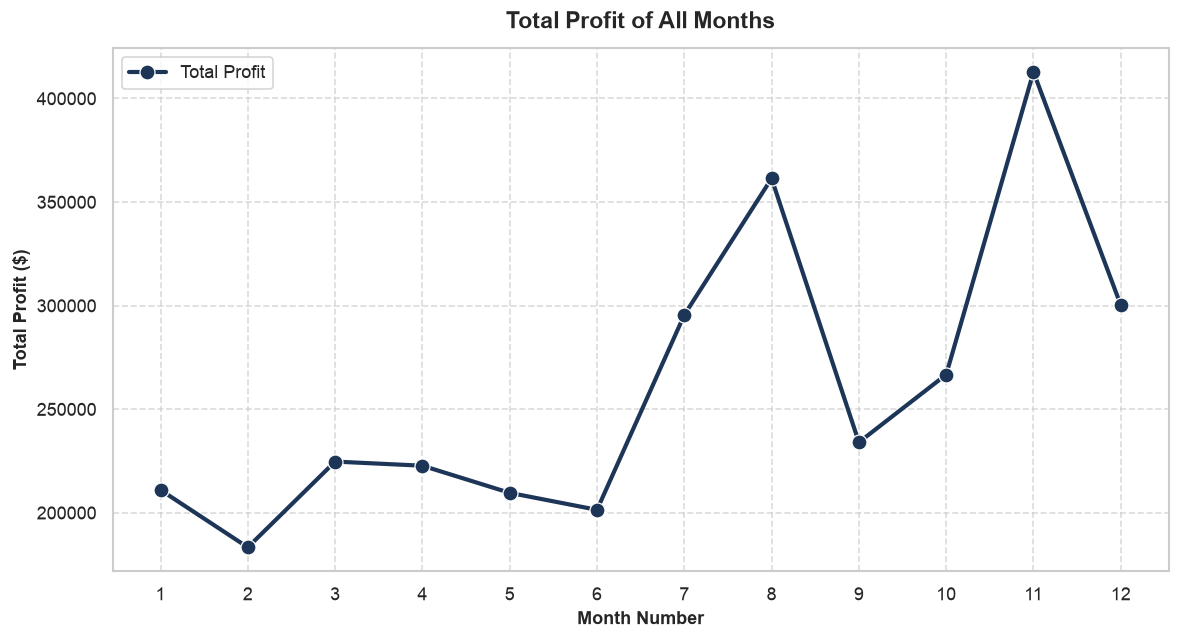

In [5]:
plt.figure(figsize=(10, 5.5))
sns.lineplot(
    data=sales_df,
    x='month_number',
    y='total_profit',
    marker='o',
    markersize=9,
    color='#1D3557',
    linewidth=2.5,
    label='Total Profit'
)

plt.title('Total Profit of All Months', fontsize=14, fontweight='bold', pad=12)
plt.xlabel('Month Number', fontsize=11, fontweight='bold')
plt.ylabel('Total Profit ($)', fontsize=11, fontweight='bold')
plt.xticks(sales_df['month_number'])
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()


#### **Part 2: All Product Sales Data using Multiline Plot**

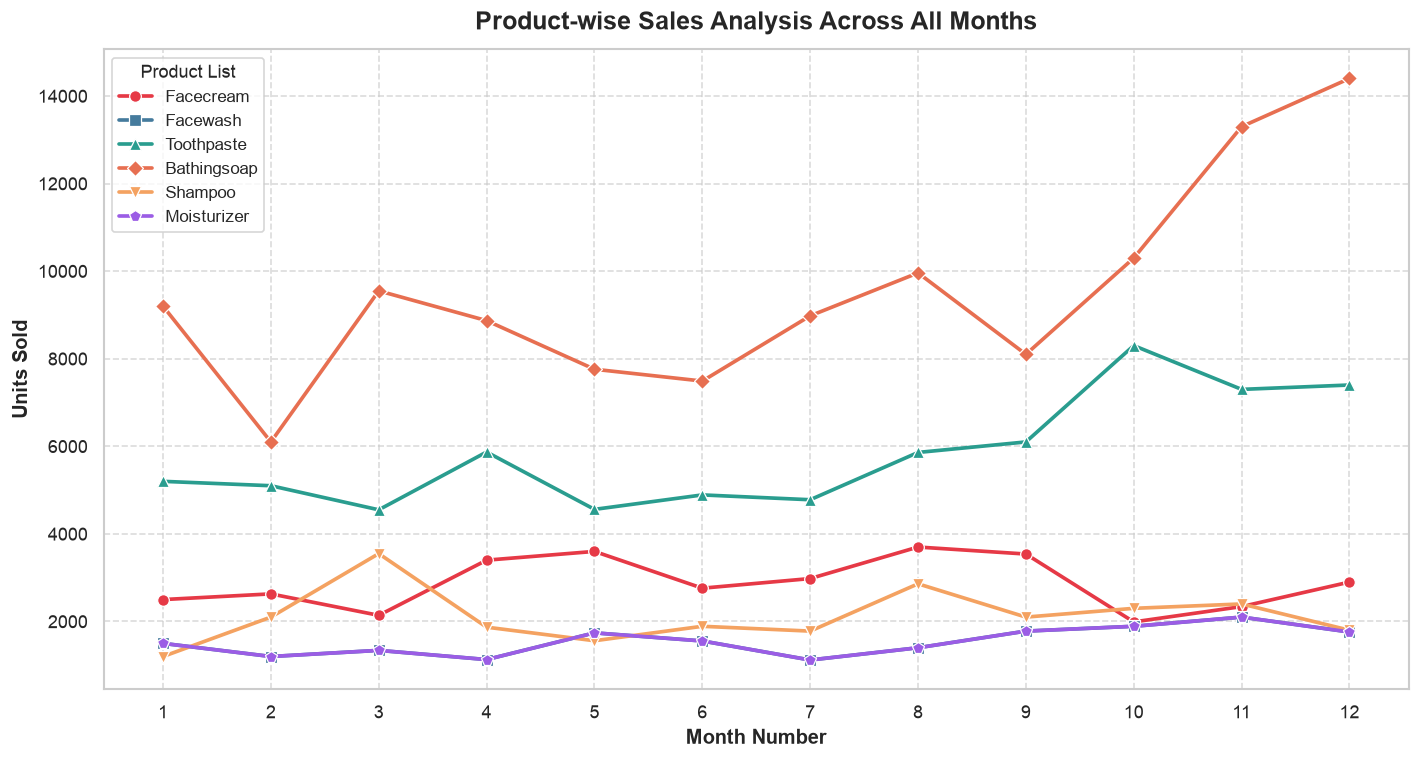

In [6]:
products = ['facecream', 'facewash', 'toothpaste', 'bathingsoap', 'shampoo', 'moisturizer']
product_colors = ['#E63946', '#457B9D', '#2A9D8F', '#E76F51', '#F4A261', '#9B5DE5']
markers = ['o', 's', '^', 'D', 'v', 'p']

plt.figure(figsize=(12, 6.5))
for prod, col, mk in zip(products, product_colors, markers):
    sns.lineplot(
        data=sales_df,
        x='month_number',
        y=prod,
        label=prod.capitalize(),
        color=col,
        marker=mk,
        markersize=7,
        linewidth=2.2
    )

plt.title('Product-wise Sales Analysis Across All Months', fontsize=15, fontweight='bold', pad=12)
plt.xlabel('Month Number', fontsize=12, fontweight='bold')
plt.ylabel('Units Sold', fontsize=12, fontweight='bold')
plt.xticks(sales_df['month_number'])
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='Product List', title_fontsize='11', fontsize=10, loc='upper left')
plt.tight_layout()
plt.show()


#### **Part 3: Bar Chart for All Features/Attributes**

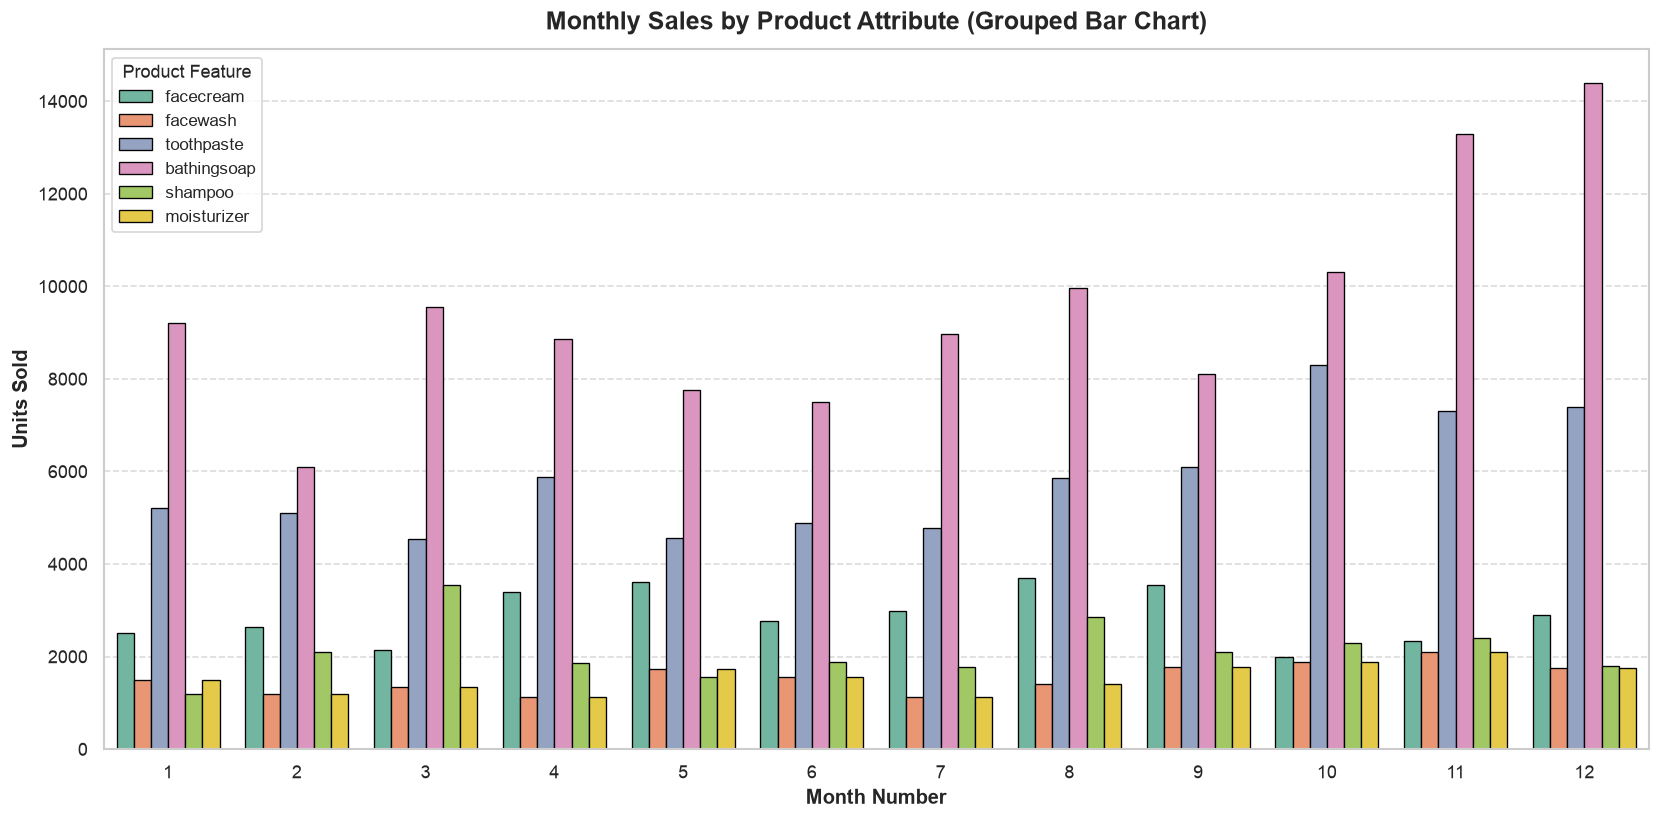

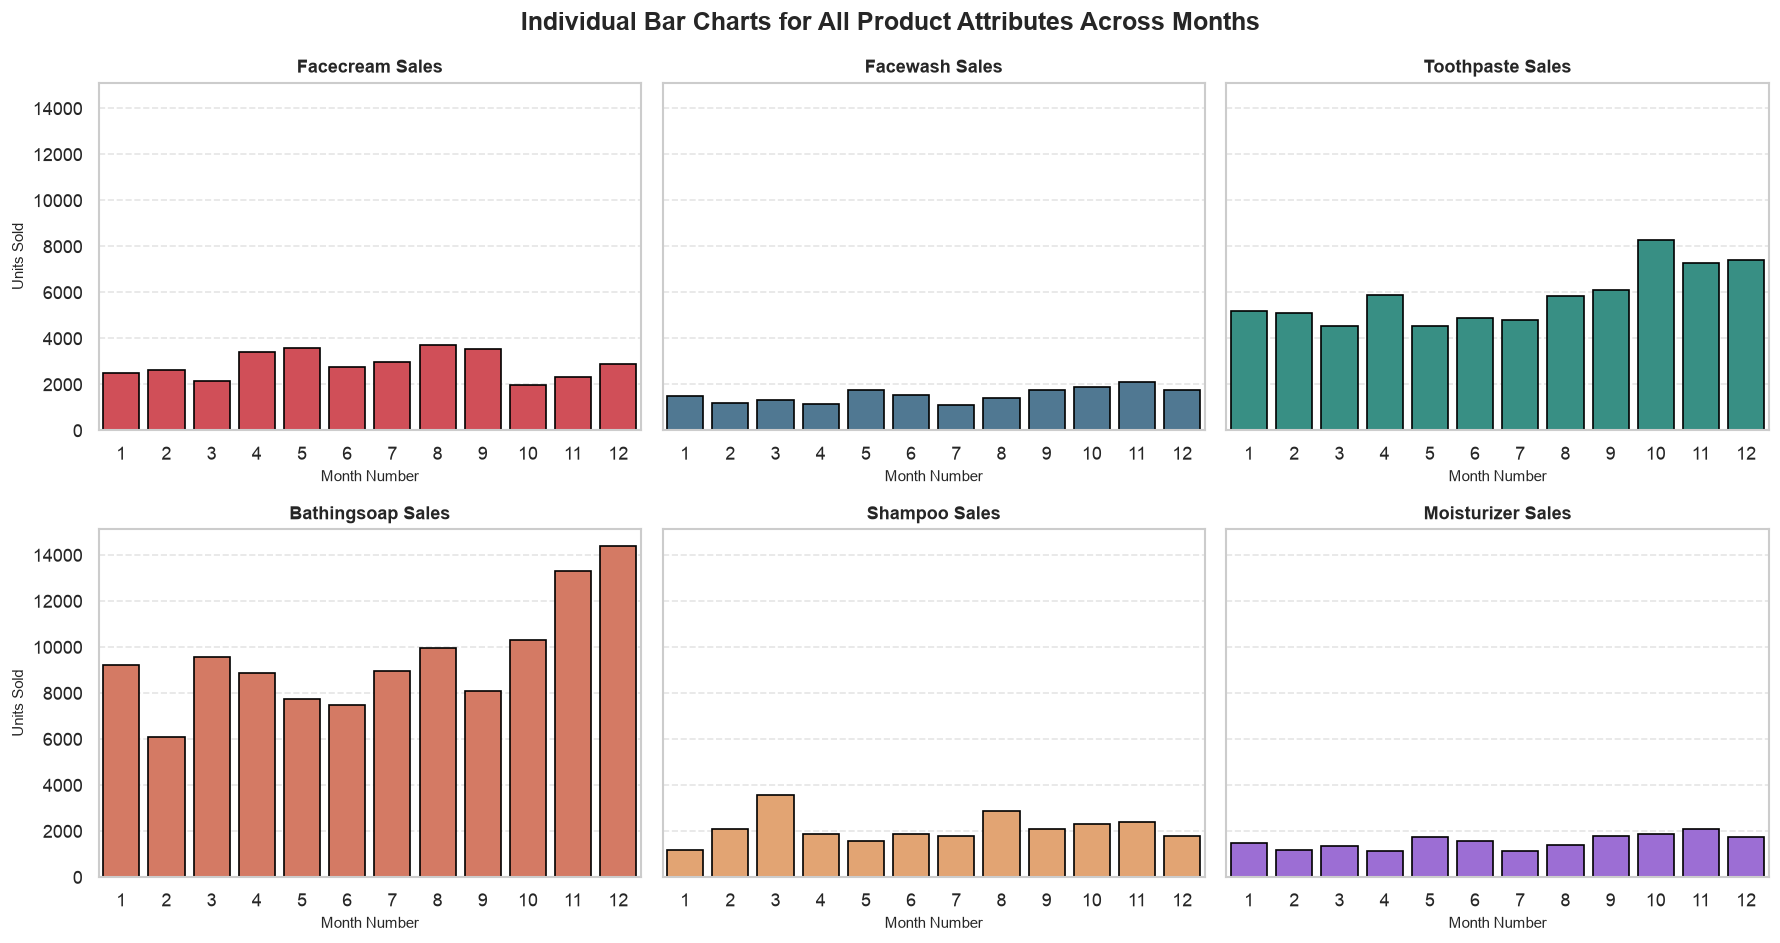

In [7]:
melted_df = sales_df.melt(
    id_vars=['month_number'],
    value_vars=products,
    var_name='Product',
    value_name='Units Sold'
)

plt.figure(figsize=(14, 7))
sns.barplot(
    data=melted_df,
    x='month_number',
    y='Units Sold',
    hue='Product',
    palette='Set2',
    edgecolor='black',
    linewidth=0.8
)

plt.title('Monthly Sales by Product Attribute (Grouped Bar Chart)', fontsize=15, fontweight='bold', pad=12)
plt.xlabel('Month Number', fontsize=12, fontweight='bold')
plt.ylabel('Units Sold', fontsize=12, fontweight='bold')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Product Feature', title_fontsize='11', fontsize=10)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharey=True)
fig.suptitle('Individual Bar Charts for All Product Attributes Across Months', fontsize=15, fontweight='bold')

for idx, (prod, ax) in enumerate(zip(products, axes.flatten())):
    sns.barplot(
        data=sales_df,
        x='month_number',
        y=prod,
        ax=ax,
        color=product_colors[idx],
        edgecolor='black'
    )
    ax.set_title(f'{prod.capitalize()} Sales', fontsize=11, fontweight='bold')
    ax.set_xlabel('Month Number', fontsize=9)
    ax.set_ylabel('Units Sold' if idx % 3 == 0 else '', fontsize=9)
    ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()
